In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
from rdkit.Chem import PandasTools
import rdkit
print(rdkit.__version__)

def show_df(df):
    print(df.shape)
    return HTML(df[:5].to_html(notebook=True))

fname = 'data/dye_data/Absorption/Continuous/'
fname = fname + 'wavelength-max-absorption_continuous_380-to-700-\
nm_ClCCl-solvent_deep4chem-and-smfluo-databases.sdf'

df = PandasTools.LoadSDF(fname,smilesName='SMILES',molColName='Molecule',
                          includeFingerprints=False, removeHs=False, strictParsing=False)

2022.03.3


In [3]:
df = df.drop(['ID','Solvent','Database','InChIKey','Molecule'],axis=1,errors='ignore')
df

,Compound_name,Outcome,SMILES
0,9927,436.0,CC(C)(C)c1ccc(-c2ccc(-c3ccc(N(c4ccccc4)c4ccccc...
1,15654,403.0,CCC1(CC)c2ccccc2-c2ccc(C#Cc3ccc4ccc5cccc6ccc3c...
2,7417,430.0,CN(C)c1ccc(C2=Nc3sc4cc(Cl)ccc4[n+]3[B-](F)(F)O...
3,4772,473.0,c1ccc(-c2ccc3c4ccc(-c5ccccc5)c5c(-c6ccccc6)ccc...
4,13605,467.0,CCN(CC)/C(C)=N\c1ccc2c3c(cccc13)C(=O)c1ccccc1-2
...,...,...,...
1545,4990,535.0,COc1ccc(C2=C(C)C3=C(c4c(-c5ccccn5)nc5ccccn45)c...
1546,16759,386.0,CCCCCCCCCCCCCCCC[n+]1ccc(/C=C(\C)c2ccccc2)cc1
1547,17804,616.0,CCc1c(C)c2n(c1C)[B-](F)(F)[N+]1=C(c3ccc[nH]3)c...
1548,12551,467.0,CCCCC(CC)Cn1c2cc(C#N)ccc2c2ccc(C#Cc3cc(C#Cc4cc...


In [4]:
# https://stackoverflow.com/questions/40581878/gradient-with-spectral-lines

def lin_inter(value, left=0., right=1., increase=True):
    """
    Returns the fractional position of ``value`` between ``left`` and
    ``right``, increasing from 0 if ``value==left`` to 1 if ``value==right``,
    or decreasing from 1 to zero if not ``increase``.
    """
    if increase:
        return (value - left) / (right - left)
    else:
        return (right - value) / (right - left)
    
def wav2RGB(Wavelength, upto255=False, Gamma=1.0):
    
    if isinstance(Wavelength, str):
        Wavelength = float(Wavelength)
    """
    Converts an wavelength to an RGB list, with fractional values between
    0 and 1 if not ``upto255``, or int values between 0 and 255 if ``upto255``
    """
    # Check the interval the color is in
    if 380 <= Wavelength < 440:
        # red goes from 1 to 0:
        Red = lin_inter(Wavelength, 380., 440., False)
        Green = 0.0
        Blue = 1.0
    elif 440 <= Wavelength < 490:
        Red = 0.0
        # green goes from 0 to 1:
        Green = lin_inter(Wavelength, 440., 490., True)
        Blue = 1.0
    elif 490 <= Wavelength < 510:
        Red = 0.0
        Green = 1.0
        Blue = lin_inter(Wavelength, 490., 510., False)
    elif 510 <= Wavelength < 580:
        Red = lin_inter(Wavelength, 510., 580., True)
        Green = 1.0
        Blue = 0.0
    elif 580 <= Wavelength < 645:
        Red = 1.0
        Green = lin_inter(Wavelength, 580., 645., False)
        Blue = 0.0
    elif 645 <= Wavelength <= 780:
        Red = 1.0
        Green = 0.0
        Blue = 0.0
    else: # Wavelength < 380 or Wavelength > 780
        Red = 0.0
        Green = 0.0
        Blue = 0.0
    # Let the intensity fall off near the vision limits
    if 380 <= Wavelength < 420:
        factor = 0.3 + 0.7*lin_inter(Wavelength, 380., 420., True)
    elif 420 <= Wavelength < 700:
        factor = 1.0
    elif 700 <= Wavelength <= 780:
        factor = 0.3 + 0.7*lin_inter(Wavelength, 700., 780., False)
    else:
        factor = 0.0
    # Adjust color intensity
    if upto255:
        def Adjust(Color, Factor):
            return int(round(255. * (Color * Factor)**Gamma))
    else:
        def Adjust(Color, Factor):
            return (Color * Factor)**Gamma
    R = Adjust(Red, factor)
    G = Adjust(Green, factor)
    B = Adjust(Blue, factor)
    #return color
    return [R, G, B]

In [5]:
def rgb2hex(rgb):
    rgb = [float(x) for x in rgb]
    rgb = [255*x for x in rgb]
    rgb = [int(x) for x in rgb]
    r,g,b = rgb[0], rgb[1], rgb[2]
    return "#{:02x}{:02x}{:02x}".format(r,g,b)

df['RGB'] = df.Outcome.apply(lambda x: wav2RGB(x))
df['hex'] = df.RGB.apply(lambda x: rgb2hex(x))
df

,Compound_name,Outcome,SMILES,RGB,hex
0,9927,436.0,CC(C)(C)c1ccc(-c2ccc(-c3ccc(N(c4ccccc4)c4ccccc...,"[0.06666666666666667, 0.0, 1.0]",#1100ff
1,15654,403.0,CCC1(CC)c2ccccc2-c2ccc(C#Cc3ccc4ccc5cccc6ccc3c...,"[0.4332083333333333, 0.0, 0.7024999999999999]",#6e00b3
2,7417,430.0,CN(C)c1ccc(C2=Nc3sc4cc(Cl)ccc4[n+]3[B-](F)(F)O...,"[0.16666666666666666, 0.0, 1.0]",#2a00ff
3,4772,473.0,c1ccc(-c2ccc3c4ccc(-c5ccccc5)c5c(-c6ccccc6)ccc...,"[0.0, 0.66, 1.0]",#00a8ff
4,13605,467.0,CCN(CC)/C(C)=N\c1ccc2c3c(cccc13)C(=O)c1ccccc1-2,"[0.0, 0.54, 1.0]",#0089ff
...,...,...,...,...,...
1545,4990,535.0,COc1ccc(C2=C(C)C3=C(c4c(-c5ccccn5)nc5ccccn45)c...,"[0.35714285714285715, 1.0, 0.0]",#5bff00
1546,16759,386.0,CCCCCCCCCCCCCCCC[n+]1ccc(/C=C(\C)c2ccccc2)cc1,"[0.3645, 0.0, 0.40499999999999997]",#5c0067
1547,17804,616.0,CCc1c(C)c2n(c1C)[B-](F)(F)[N+]1=C(c3ccc[nH]3)c...,"[1.0, 0.4461538461538462, 0.0]",#ff7100
1548,12551,467.0,CCCCC(CC)Cn1c2cc(C#N)ccc2c2ccc(C#Cc3cc(C#Cc4cc...,"[0.0, 0.54, 1.0]",#0089ff


(1550, 3)


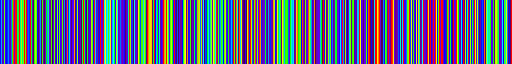

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

spectra = df.Outcome.values
spectra = spectra.astype(np.float)
rgbs = np.asarray(list(map(wav2RGB, spectra)))
print(rgbs.shape)

my_cmap = ListedColormap(rgbs, name='my_colormap_name')
my_cmap

In [9]:
import copy
df_style = copy.deepcopy(df)

df_style[:10].style.applymap(lambda x:"background-color: %s"%x, subset=['hex'])

,Compound_name,Outcome,SMILES,RGB,hex
0,9927,436.0,CC(C)(C)c1ccc(-c2ccc(-c3ccc(N(c4ccccc4)c4ccccc4)cc3)c3nsnc23)cc1,"[0.06666666666666667, 0.0, 1.0]",#1100ff
1,15654,403.0,CCC1(CC)c2ccccc2-c2ccc(C#Cc3ccc4ccc5cccc6ccc3c4c56)cc21,"[0.4332083333333333, 0.0, 0.7024999999999999]",#6e00b3
2,7417,430.0,CN(C)c1ccc(C2=Nc3sc4cc(Cl)ccc4[n+]3[B-](F)(F)O2)cc1,"[0.16666666666666666, 0.0, 1.0]",#2a00ff
3,4772,473.0,c1ccc(-c2ccc3c4ccc(-c5ccccc5)c5c(-c6ccccc6)ccc(c6cccc2c63)c54)cc1,"[0.0, 0.66, 1.0]",#00a8ff
4,13605,467.0,CCN(CC)/C(C)=N\c1ccc2c3c(cccc13)C(=O)c1ccccc1-2,"[0.0, 0.54, 1.0]",#0089ff
5,7762,622.0,CC(C)c1cccc(C(C)C)c1N1C(=O)c2ccc3c(-c4ccc(C(=O)O)cc4)c4c5ccc6c7c(ccc(c(-c8ccc(C(=O)O)cc8)c4c4ccc(c2c34)C1=O)c75)C(=O)N(c1c(C(C)C)cccc1C(C)C)C6=O,"[1.0, 0.35384615384615387, 0.0]",#ff5a00
6,889,400.0,[O-][n+]1c(/C=C/C=C/c2ccccc2)nc(N2CCOCC2)c2c1CCCC2,"[0.43333333333333324, 0.0, 0.6499999999999999]",#6e00a5
7,19062,411.0,Nc1ccc2c(c1)oc(=O)c1c(=O)oc3ccccc3c12,"[0.40720833333333334, 0.0, 0.8425]",#6700d6
8,13488,426.0,CCC1(CC)c2cc(/C=C/c3cc(Br)c(/C=C/c4ccc5c(c4)C(CC)(CC)c4cc(N6c7ccccc7Sc7ccccc76)ccc4-5)cc3Br)ccc2-c2ccc(N3c4ccccc4Sc4ccccc43)cc21,"[0.23333333333333334, 0.0, 1.0]",#3b00ff
9,9586,427.0,COc1cc2c(cc1C=C(C#N)C#N)c1ccccc1n2C,"[0.21666666666666667, 0.0, 1.0]",#3700ff
